In [12]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [13]:
#Load Dataset
df = pd.read_csv('Mall_Customers.csv')

In [14]:
#View Dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
#Select Features
X = df.iloc[:, [3,4]].values

In [16]:
#Find Best Number of Clusters
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

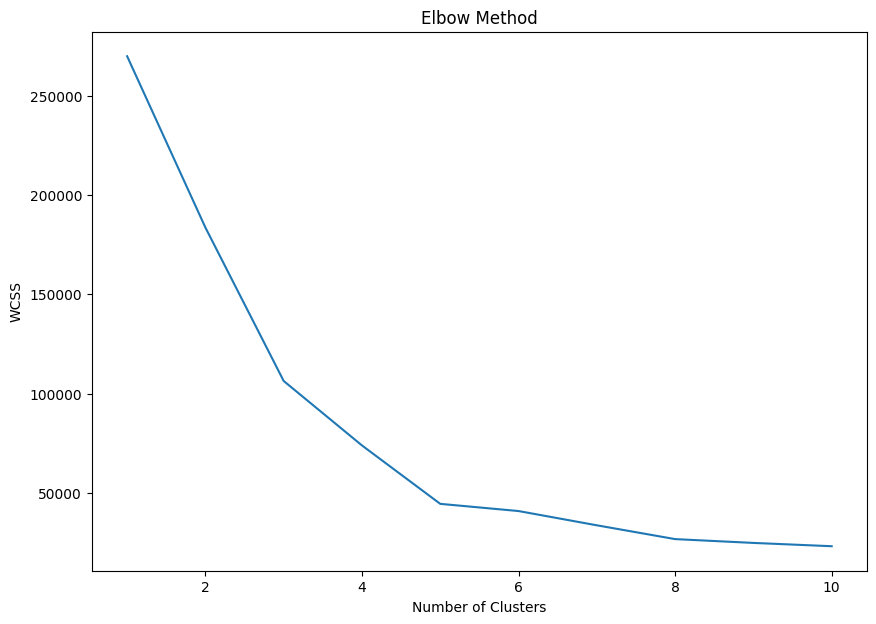

In [18]:
#Plot Elbow Graph
plt.figure(figsize=(10,7))

plt.plot(range(1,11), wcss)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [19]:
#Train K-Means Model
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

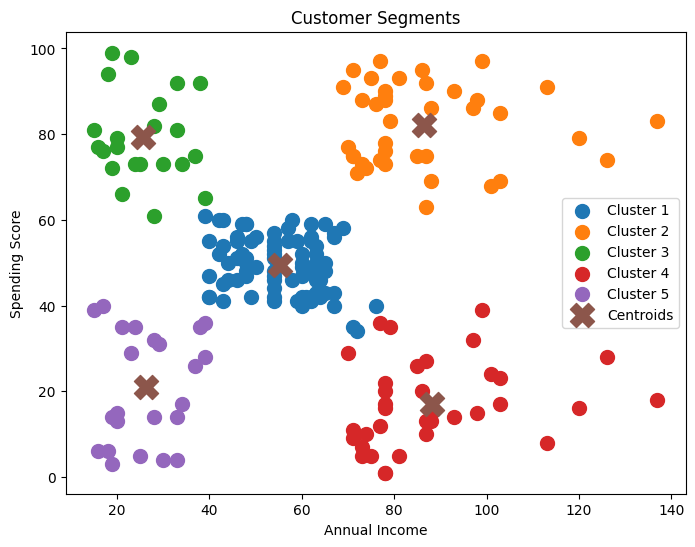

In [20]:
#Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0, 0],
            X[y_kmeans == 0, 1],
            s=100,
            label='Cluster 1')

plt.scatter(X[y_kmeans == 1, 0],
            X[y_kmeans == 1, 1],
            s=100,
            label='Cluster 2')

plt.scatter(X[y_kmeans == 2, 0],
            X[y_kmeans == 2, 1],
            s=100,
            label='Cluster 3')

plt.scatter(X[y_kmeans == 3, 0],
            X[y_kmeans == 3, 1],
            s=100,
            label='Cluster 4')

plt.scatter(X[y_kmeans == 4, 0],
            X[y_kmeans == 4, 1],
            s=100,
            label='Cluster 5')

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.legend()

plt.show()